# A/B testing
### Jimmy Azar

## Introduction

In this lab, we'll apply A/B testing over three different marketing campaigns. 

A fast food company has plans to introduce a new item to its menu. The company has come up with three different marketing campaigns to promote its new product. The three campaigns were conducted at several locations and in several markets. Weekly sales of the new product were recorded over the first 4 weeks. The company wants to find out which of the three promotions has the largest impact on sales.

(1) The first strategy is based on providing a collectible item with each purchase of the new product and is aimed mostly at kids. The idea is to entice customers into returning until they have completed their collection of items.

(2) The second marketing strategy is societal and promotes the idea of fundraising for a cause or charity. It targets customers who might relate to the ideas/values of the charitable work. 

(3) The third strategy is based on loyalty programs. Customers are invited to subscribe or are given coupons, and they receive rewards (e.g. free drinks, fries, meal) based on the frequency of orders they make for a particular product. 

## Data exploration

We load and inspect the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data exploration
path_to_file = '../data/marketing_campaign.csv'
df = pd.read_csv(path_to_file)
print(df.head())

print(df.shape)

df['sales_in_thousands'].describe()

   market_ID market_size  location  store_age  promotion  week  \
0          1      Medium         1          4          3     1   
1          1      Medium         1          4          3     2   
2          1      Medium         1          4          3     3   
3          1      Medium         1          4          3     4   
4          1      Medium         2          5          2     1   

   sales_in_thousands  
0               33.73  
1               35.67  
2               29.03  
3               39.25  
4               27.81  
(548, 7)


count    548.000000
mean      53.466204
std       16.755216
min       17.340000
25%       42.545000
50%       50.200000
75%       60.477500
max       99.650000
Name: sales_in_thousands, dtype: float64

### Sales per promotion strategy

Let's create a pie chart showing sales across different promotions.

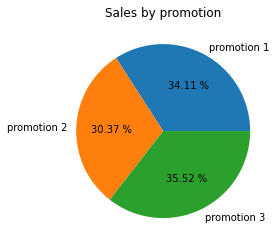

In [2]:
# sales per promotion strategy
sales_per_promo = df[['promotion','sales_in_thousands']].copy()
sales_per_promo = sales_per_promo.groupby(['promotion']).aggregate({'sales_in_thousands':'sum'})

sales_per_promo.idxmax()[0] 

labels = [f'promotion {i}' for i in sales_per_promo.index.tolist()]
plt.pie(sales_per_promo['sales_in_thousands'], labels=labels, autopct='%2.2f %%')
plt.title("Sales by promotion")
plt.show()

### Market size per promotion 

Next, we create a data frame showing market_size and count. Then, we create another data frame with three columns: promotion, market_size, and count, where the last column indicates the frequency of occurence of each pair of (promotion, market_size).

In [3]:
# market size per promotion
df_market_size = df['market_size'].value_counts()
print(df_market_size)

df_market_size_per_promo = df.groupby(['promotion','market_size'], as_index=False).aggregate({'sales_in_thousands':'count'}) 
df_market_size_per_promo.rename(columns={'sales_in_thousands':'count'}, inplace=True)
df_market_size_per_promo

Medium    320
Large     168
Small      60
Name: market_size, dtype: int64


,promotion,market_size,count
0,1,Large,56
1,1,Medium,96
2,1,Small,20
3,2,Large,64
4,2,Medium,108
5,2,Small,16
6,3,Large,48
7,3,Medium,116
8,3,Small,24


We plot a bar chart showing the three promotions on the x-axis and three bars for each promotion (corresponding to the three market size types). Also, we'll generate a stacked bar plot.

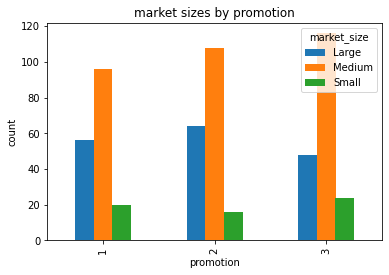

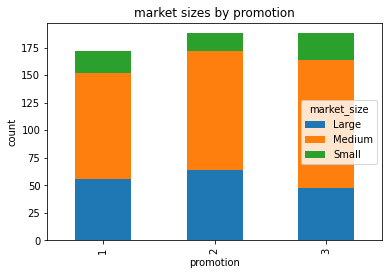

promotion
1    Medium
2    Medium
3    Medium
dtype: object

In [4]:
# bar-plot
# using pd.pivot_table()
df_temp = df_market_size_per_promo.pivot_table(index='promotion', columns='market_size', values='count')

df_temp.plot(kind='bar', stacked=False) 
plt.title('market sizes by promotion')
plt.ylabel('count')
plt.show()

df_temp.plot(kind='bar', stacked=True)
plt.title('market sizes by promotion')
plt.ylabel('count')
plt.show()

df_temp.T.idxmax()

### Age of stores

We generate a statistics summary for the ages of stores. We also generate two subplots side by side: a bar plot showing the count of the different store ages, and a box plot for store ages.

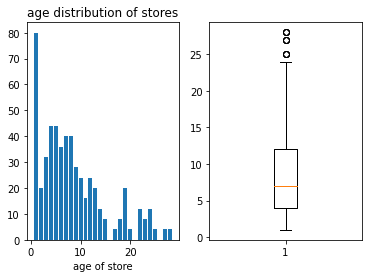

store_age    1
dtype: int64

In [5]:
# age of stores
df['store_age'].describe()

df['store_age'].value_counts()

fig, ax = plt.subplots(1,2)
ax[0].bar(df['store_age'].value_counts().index, df['store_age'].value_counts())
ax[0].set_xlabel('age of store')
ax[0].set_title('age distribution of stores')

ax[1].boxplot(df['store_age'])
plt.show()

pd.DataFrame(df['store_age'].value_counts()).idxmax()

## A/B testing

We create a scatter plot with promotion strategy on the x-axis and sales on the y-axis. Also, we create a figure with 3 horizontal box plots.

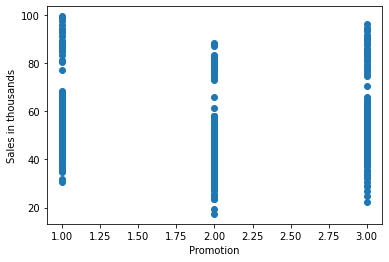

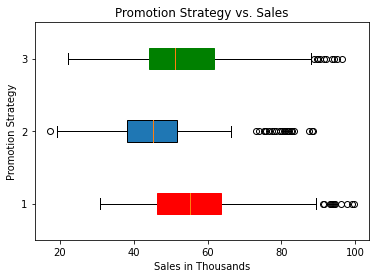

In [6]:
# scatter plot
plt.scatter(df['promotion'], df['sales_in_thousands'])
plt.xlabel('Promotion')
plt.ylabel('Sales in thousands')
plt.show()


# boxplot
sales1 = df.loc[df['promotion'] == 1, 'sales_in_thousands']
sales2 = df.loc[df['promotion'] == 2, 'sales_in_thousands']
sales3 = df.loc[df['promotion'] == 3, 'sales_in_thousands'] 

h = plt.boxplot([sales1, sales2, sales3], patch_artist=True, labels=[1,2,3], vert=False)
plt.setp(h['boxes'][0], color='red')
plt.setp(h['boxes'][2], color='green')
plt.ylabel('Promotion Strategy')
plt.xlabel('Sales in Thousands')
plt.title('Promotion Strategy vs. Sales')
plt.show()

Finally, let's test whether the difference between promotion strategies 1, 2, and 3 are statistically significant or not. We compute the mean, standard deviation, and number of samples for each of the sales (in thousands) corresponding to promotions 1, 2, and 3. Finally, we're ready to apply a two-sample t-test. In particular, we'll use the most general case, assuming variances are unknown and not necessarily equal: 

$$H_0: \mu_1 - \mu_2 = 0$$

$$H_1: \mu_1 - \mu_2 \neq 0$$

$$t_0^{*} = \dfrac{\overline{X}_1 - \overline{X}_2}{\sqrt{\dfrac{S_1^2}{n_1}+\dfrac{S_2^2}{n_2}}} $$
where $t_0^{*}$ is $t$-distributed with degrees of freedom, $v$, given by:

$$v = \dfrac{\left( \dfrac{S_1^2}{n_1}+\dfrac{S_2^2}{n_2} \right)^2}{\dfrac{(S_1^2/n_1)^2}{n_1-1}+\dfrac{(S_2^2/n_2)^2}{n_2-1}}$$

**Promotion 1 vs. Promotion 2**.

We evaluate $t_0^{*}$ and then compute the p-value.

**Promotion 1 vs. Promotion 3**. 

We repeat the previous procedure for promotion 1 vs. promotion 3.

**Promotion 2 vs. Promotion 3**. 

We repeat the previous procedure for promotion 2 vs. promotion 3.

In [7]:
# statistical significance
from scipy import stats
means = df.groupby('promotion')['sales_in_thousands'].mean()
stds = df.groupby('promotion')["sales_in_thousands"].std()
ns = df.groupby('promotion')["sales_in_thousands"].count()

# promotion 1 vs. 2
t, p = stats.ttest_ind(df.loc[df['promotion']==1, 'sales_in_thousands'].values,
					   df.loc[df['promotion']==2, 'sales_in_thousands'].values,
                       equal_var=False)
print(f'p-value: {p}')

# promotion 1 vs. 3
t, p = stats.ttest_ind(df.loc[df['promotion']==1, 'sales_in_thousands'].values,
					   df.loc[df['promotion']==3, 'sales_in_thousands'].values,
                       equal_var=False)
print(f'p-value: {p}')
                                           
# promotion 3 vs. 2
t, p = stats.ttest_ind(df.loc[df['promotion']==2, 'sales_in_thousands'].values,
					   df.loc[df['promotion']==3, 'sales_in_thousands'].values,
                       equal_var=False)
print(f'p-value: {p}')

p-value: 4.2903687179871785e-10
p-value: 0.12059147742229478
p-value: 1.5692733176039892e-06


## ANOVA

ANOVA can tell us whether there is a significant difference between treatment means overall, and when there is more than one factor present (e.g. two-way ANOVA, three-way ANOVA, etc.), we can find out whether the effect of the different factors (e.g. promotion, location, store age) and their iteractions are significant or not.  

Let's run a one-way ANOVA and Tukey's pair-wise comparison test.

In [8]:
import warnings
warnings.filterwarnings('ignore')

# ANOVA
anova = stats.f_oneway(df.loc[df['promotion']==1, 'sales_in_thousands'],
					   df.loc[df['promotion']==2, 'sales_in_thousands'],
					   df.loc[df['promotion']==3, 'sales_in_thousands'])
print(anova)
anova.pvalue

# alternatively: using statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('sales_in_thousands ~ C(promotion)', data=df).fit()
table = sm.stats.anova_lm(model)
table

F_onewayResult(statistic=21.953485793080677, pvalue=6.765849261408714e-10)


,df,sum_sq,mean_sq,F,PR(>F)
C(promotion),2.0,11449.174291,5724.587145,21.953486,6.765849e-10
Residual,545.0,142114.105414,260.759826,NaN,NaN


## Tukey's pairwise test

To identify which pairs of treatments among the 3 have a significant difference in mean, we can apply Tukey's HSD test.

In [9]:
# Tukey’s pairwise test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(df['sales_in_thousands'], df['promotion']))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------
